# Mapping PACE L3 data in the GoM
**Author:** Josh Harringmeyer</br>
Last updated: January 9, 2026



Fisheries research is rich in point-based observations: survey tows, catch locations, plankton samples, animal tag detections, CTD casts, acoustics, underwater imagery, what have you... These observations carry valuable biological information, and we often want to relate them to broader environmental conditions. The challenge is matching datasets efficiently across space and time. It's relatively straightforward to extract a point from a single satellite image, but going through multiple points and time stamps can be a major time-suck. So, let's take it one step at a time and set up a workflow to help us along. We're going to get some help from our friends at the [Southeast Area Monitoring & Assessment Program](https://seamapdata.gsmfc.org/), or SEAMAP. There is a lot of really cool fisheries data pertaining to the U.S. Gulf Coast in here (species, size, abundance, environmental parameters, and more) for us to experiment with.

> Learning Objectives:  

> 2. Import data from a NOAA Fisheries survey and show the locations on a satellite image
> 3. Extract PACE reflectance data across multiple corresponding dates/locations
> 3. Perform a rudimentary prediction model of fish abundance from the data

## *Are you ready?*

## Let’s dive in! 🐠


Let's just get a quick look at where we've targeted.

Oooooh, Chandeleur Islands! The land of pelicans and baby sharks (doo-doo doo-doo-doo-doo)! Okay, let's grab our PACE image using the date we defined above.

QUEUEING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/4 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

...

PROCESSING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/3 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/3 [00:00<?, ?it/s]

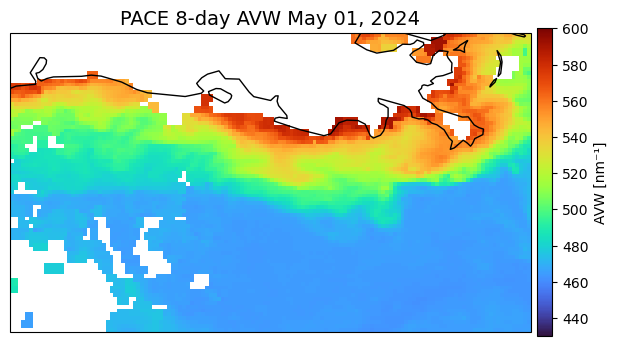

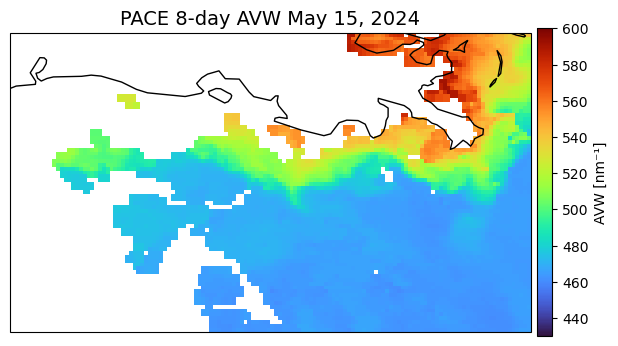

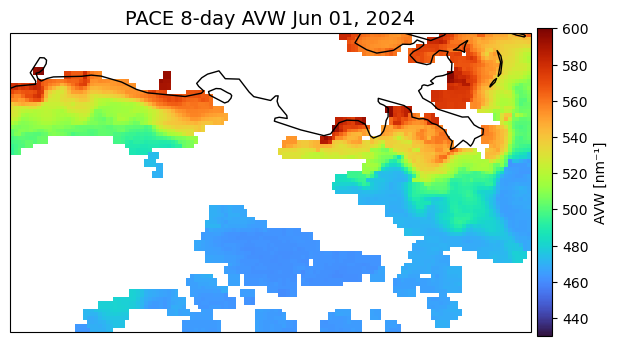

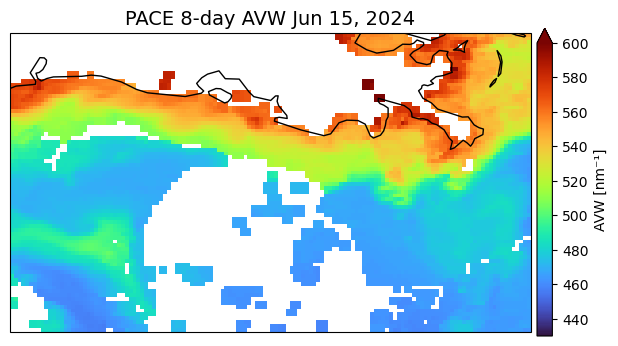

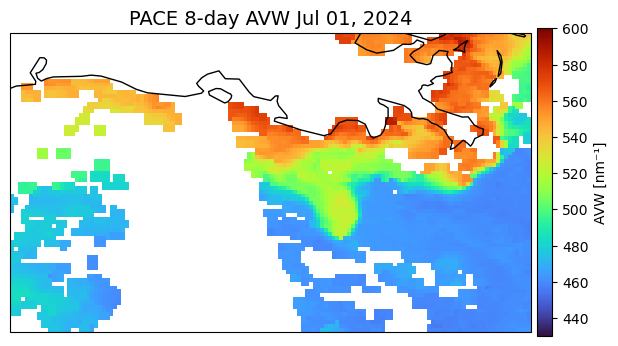

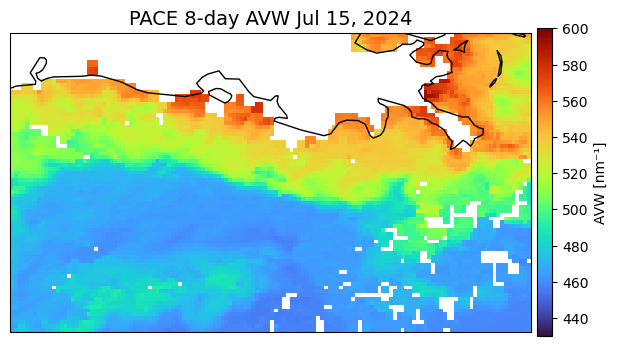

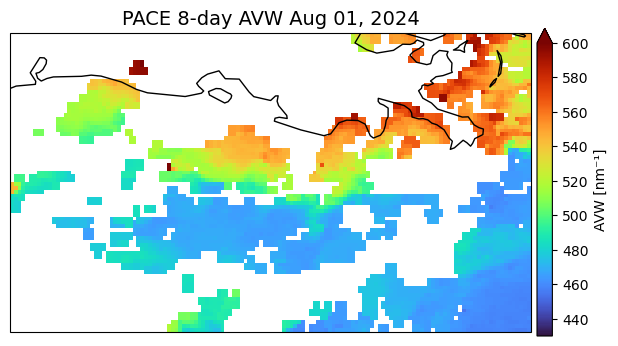

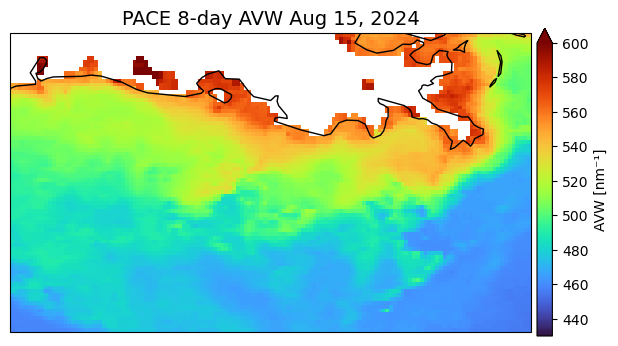

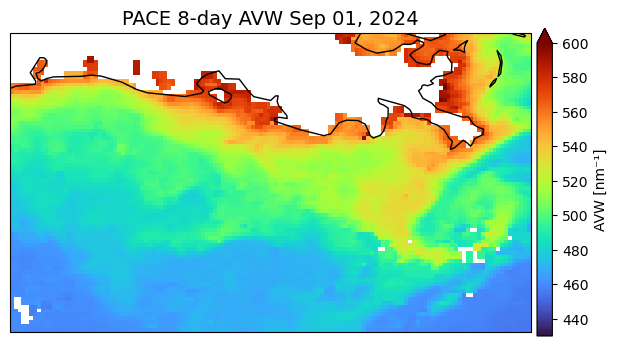

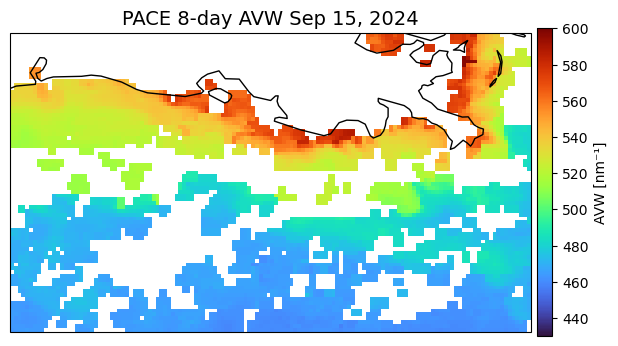

In [10]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import earthaccess
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import datetime as dt


imDays = [d for i in range(5, 10)  for d in (f'2024-{i:02d}-01', f'2024-{i:02d}-15')]
# imDays = [f'2024-{i:02d}-15' for i in range(5, 10)]
auth = earthaccess.login()

for dd in imDays:
    # Logins
    d1=dt.datetime.strptime(dd, "%Y-%m-%d")
    t0 = (d1 - dt.timedelta(days=10)).strftime("%Y-%m-%d")
    t1 = (d1 + dt.timedelta(days=10)).strftime("%Y-%m-%d")

    results = earthaccess.search_data(
    short_name="PACE_OCI_L3M_AVW",#"PACE_OCI_L3M_RRS",
    temporal=(t0, t1),
    granule_name = "*.8D.*.4km.*")
    
    fileset = earthaccess.open(results)
    ds = xr.open_dataset(fileset[0])
    # ds_gulf = ds.sel(lat=slice(30.5, 25), lon=slice(-97, -83))
    ds_gulf = ds.sel(lat=slice(30.25, 27), lon=slice(-94.15, -88.5))


    fig, ax = plt.subplots(figsize=(8, 6.66), subplot_kw={"projection": ccrs.PlateCarree()})
    ds_gulf["avw"].plot(ax=ax, cmap="turbo", add_colorbar=True, vmin=430, vmax=600,cbar_kwargs={"label": "AVW [nm⁻¹]","shrink": 0.6,"pad": 0.01})
    ax.coastlines(resolution="50m")
    ax.set_title(f"PACE 8-day AVW {d1.strftime("%b %d, %Y")}", fontsize=14)
    plt.savefig(f"PACE_AVW_8d_{d1.strftime("%b %d %Y")}.png", dpi=300, bbox_inches='tight')

QUEUEING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/4 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/4 [00:00<?, ?it/s]

...

PROCESSING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/3 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/3 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/3 [00:00<?, ?it/s]

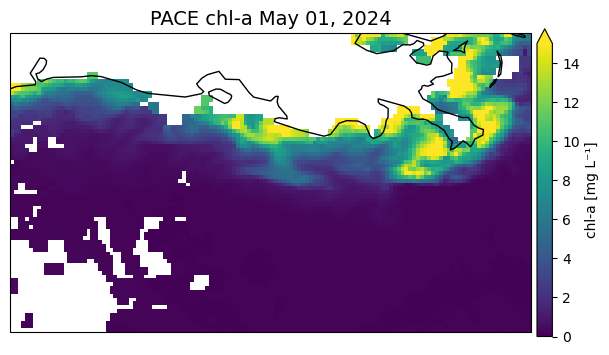

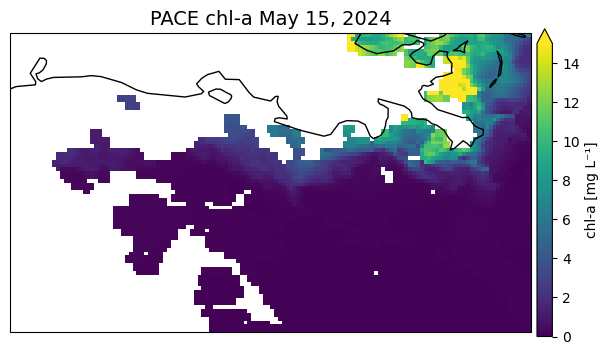

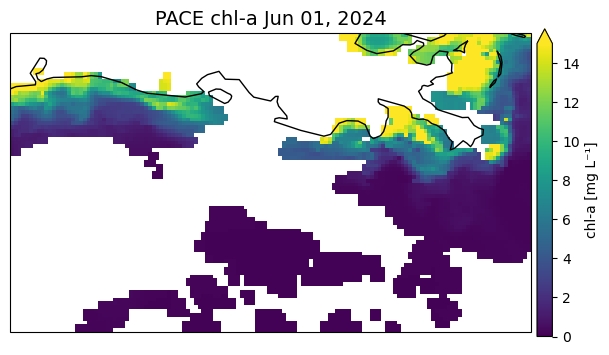

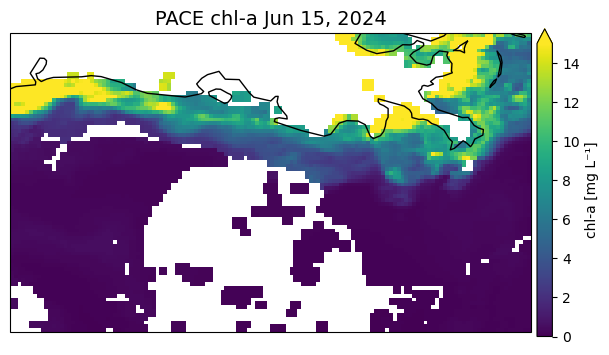

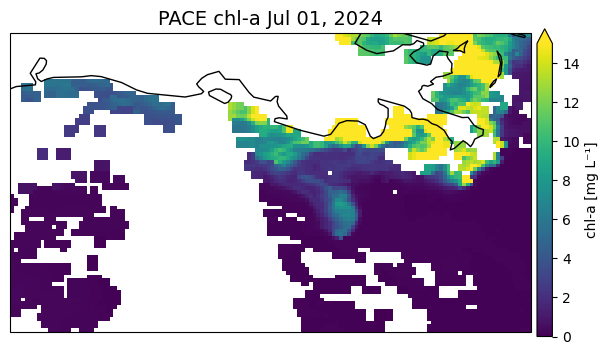

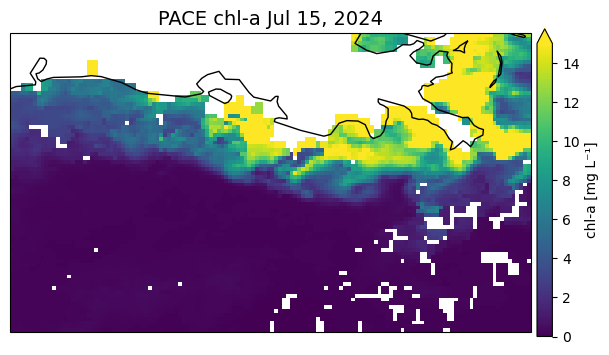

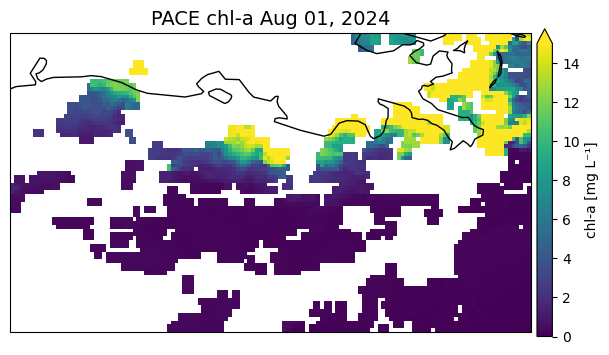

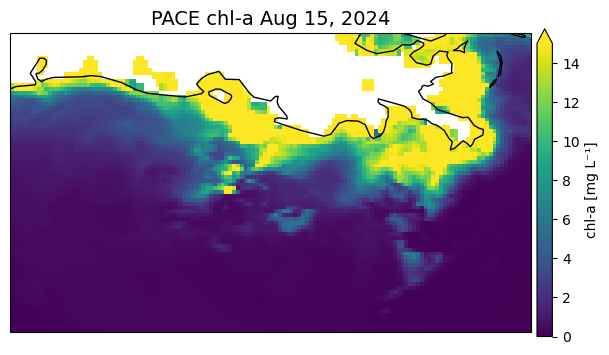

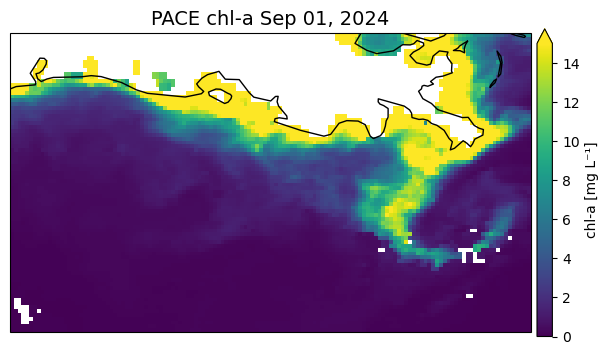

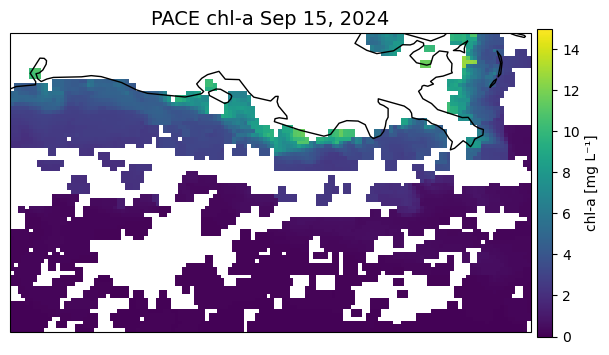

In [11]:
for dd in imDays:
    # Logins
    d1=dt.datetime.strptime(dd, "%Y-%m-%d")
    t0 = (d1 - dt.timedelta(days=10)).strftime("%Y-%m-%d")
    t1 = (d1 + dt.timedelta(days=10)).strftime("%Y-%m-%d")
    results = earthaccess.search_data(
    short_name="PACE_OCI_L3M_CHL",#"PACE_OCI_L3M_RRS",
    temporal=(t0, t1),
    granule_name = "*.8D.*.4km.*"
    )
    
    fileset = earthaccess.open(results)
    ds = xr.open_dataset(fileset[0])
    ds_gulf = ds.sel(lat=slice(30.25, 27), lon=slice(-94.15, -88.5))
    # ds_gulf = ds.sel(lat=slice(30.5, 25), lon=slice(-97, -83))

    fig, ax = plt.subplots(figsize=(8, 6.66), subplot_kw={"projection": ccrs.PlateCarree()})
    ds_gulf["chlor_a"].plot(ax=ax, cmap="viridis", add_colorbar=True, vmin=0, vmax=15,cbar_kwargs={"label": "chl-a [mg L⁻¹]","shrink": 0.6,"pad": 0.01})
    ax.coastlines(resolution="50m")
    ax.set_title(f"PACE chl-a {d1.strftime("%b %d, %Y")}", fontsize=14)
    plt.savefig(f"PACE_CHL_{d1.strftime("%b %d %Y")}.png", dpi=300, bbox_inches='tight')